In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Settings for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Connection config
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '1234',  # Change to your password
    'database': 'healthcare_db'
}

ENCRYPTION_KEY = 'my_secret_key_123'

def get_data(query):
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# Load all tables
patients = get_data("SELECT * FROM patients")
doctors = get_data(f"SELECT doctor_id, CAST(AES_DECRYPT(name, '{ENCRYPTION_KEY}') AS CHAR) as name, specialty FROM doctors")
appointments = get_data("SELECT * FROM appointments")
prescriptions = get_data("SELECT * FROM prescriptions")
claims = get_data("SELECT * FROM insurance_claims")

print(f"✅ Patients: {len(patients)} rows")
print(f"✅ Doctors: {len(doctors)} rows")
print(f"✅ Appointments: {len(appointments)} rows")
print(f"✅ Prescriptions: {len(prescriptions)} rows")
print(f"✅ Claims: {len(claims)} rows")

✅ Patients: 50 rows
✅ Doctors: 10 rows
✅ Appointments: 100 rows
✅ Prescriptions: 80 rows
✅ Claims: 60 rows


C:\Users\user\AppData\Local\Temp\ipykernel_11344\2233455698.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print("\n📊 PATIENTS:")
print(f"   Missing names: {patients['name'].isna().sum()}")
print(f"   Missing ages: {patients['age'].isna().sum()}")
print(f"   Missing phones: {patients['phone'].isna().sum()}")
print(f"   Age range: {patients['age'].min()} - {patients['age'].max()}")

print("\n👨‍⚕️ DOCTORS:")
print(f"   Missing specialties: {doctors['specialty'].isna().sum()}")

print("\n📅 APPOINTMENTS:")
print(f"   Total: {len(appointments)}")
print(f"   Status distribution:")
print(appointments['status'].value_counts())

DATA QUALITY REPORT

📊 PATIENTS:
   Missing names: 0
   Missing ages: 0
   Missing phones: 0
   Age range: 0 - 120

👨‍⚕️ DOCTORS:
   Missing specialties: 0

📅 APPOINTMENTS:
   Total: 100
   Status distribution:
status
Completed    49
Scheduled    34
Cancelled    17
Name: count, dtype: int64


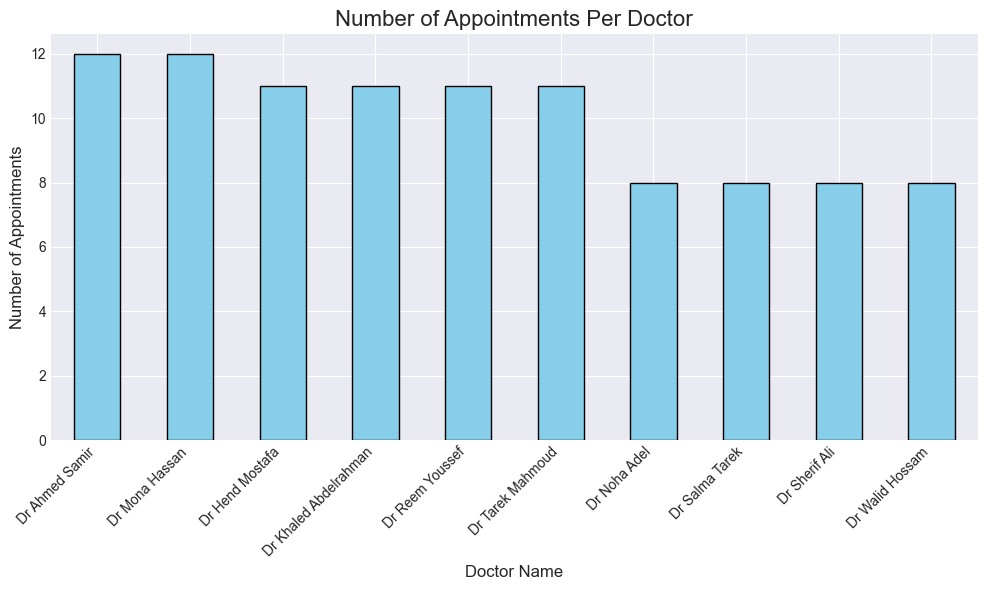


📊 Top 3 Doctors:
name
Dr Ahmed Samir     12
Dr Mona Hassan     12
Dr Hend Mostafa    11
dtype: int64

📉 Bottom 3 Doctors:
name
Dr Salma Tarek     8
Dr Sherif Ali      8
Dr Walid Hossam    8
dtype: int64


In [5]:
# Merge appointments with doctors
appt_with_doctors = appointments.merge(doctors, on='doctor_id')

# Count per doctor
doctor_visits = appt_with_doctors.groupby('name').size().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
doctor_visits.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Appointments Per Doctor', fontsize=16)
plt.xlabel('Doctor Name', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 Top 3 Doctors:")
print(doctor_visits.head(3))
print("\n📉 Bottom 3 Doctors:")
print(doctor_visits.tail(3))

C:\Users\user\AppData\Local\Temp\ipykernel_11344\2233455698.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


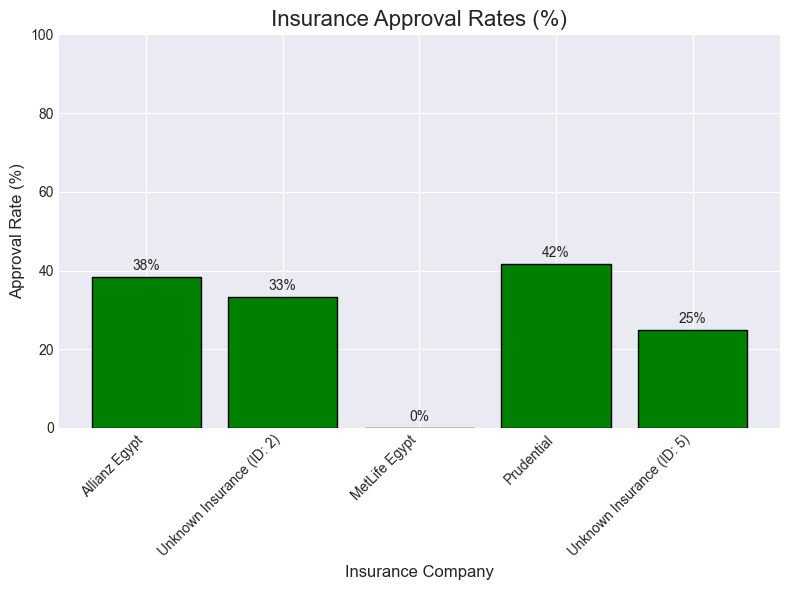

   company_id               name               display_name  total  approved  \
0           1      Allianz Egypt              Allianz Egypt     13         5   
1           2  Unknown Insurance  Unknown Insurance (ID: 2)     12         4   
2           3      MetLife Egypt              MetLife Egypt     11         0   
3           4         Prudential                 Prudential     12         5   
4           5  Unknown Insurance  Unknown Insurance (ID: 5)     12         3   

   approval_rate  
0      38.461538  
1      33.333333  
2       0.000000  
3      41.666667  
4      25.000000  


In [8]:
# Calculate approval rate per insurance company
insurance_stats = claims.groupby('insurance_company_id').agg(
    total=('claim_id', 'count'),
    approved=('status', lambda x: (x == 'Approved').sum())
).reset_index()

# Rename column
insurance_stats.rename(columns={'insurance_company_id': 'company_id'}, inplace=True)

insurance_stats['approval_rate'] = (insurance_stats['approved'] / insurance_stats['total']) * 100

# Merge with insurance names
insurance_names = get_data("SELECT company_id, name FROM insurance_companies")
insurance_stats = insurance_stats.merge(insurance_names, on='company_id')

# Fix Unknown names to show their ID
insurance_stats['display_name'] = insurance_stats.apply(
    lambda row: f"{row['name']} (ID: {row['company_id']})" if row['name'] == 'Unknown Insurance' else row['name'],
    axis=1
)

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(insurance_stats['display_name'], insurance_stats['approval_rate'], color='green', edgecolor='black')
plt.ylim(0, 100)
plt.title('Insurance Approval Rates (%)', fontsize=16)
plt.xlabel('Insurance Company', fontsize=12)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(insurance_stats[['company_id', 'name', 'display_name', 'total', 'approved', 'approval_rate']])

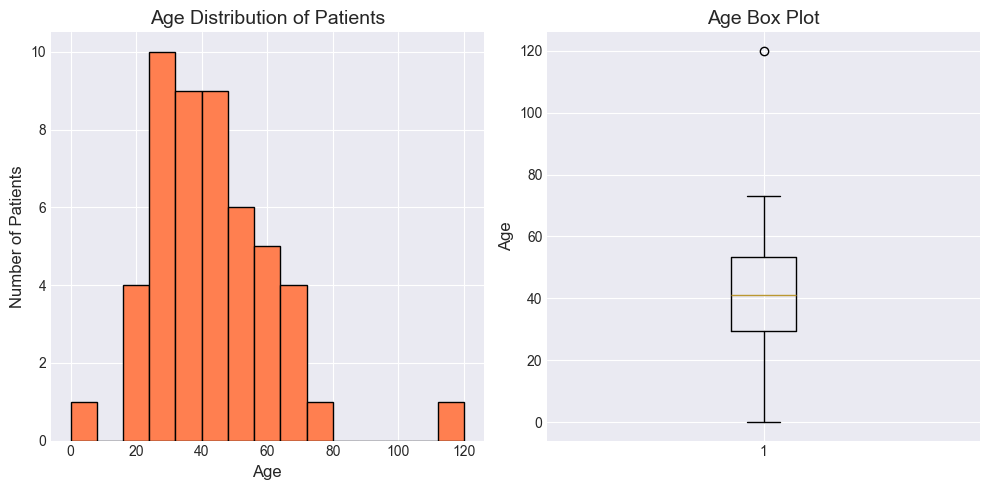

📊 Age Statistics:
   Average: 42.9 years
   Median: 41.0 years
   Std Dev: 19.3 years


In [9]:
plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(patients['age'].dropna(), bins=15, color='coral', edgecolor='black')
plt.title('Age Distribution of Patients', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(patients['age'].dropna(), vert=True)
plt.title('Age Box Plot', fontsize=14)
plt.ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

print(f"📊 Age Statistics:")
print(f"   Average: {patients['age'].mean():.1f} years")
print(f"   Median: {patients['age'].median():.1f} years")
print(f"   Std Dev: {patients['age'].std():.1f} years")

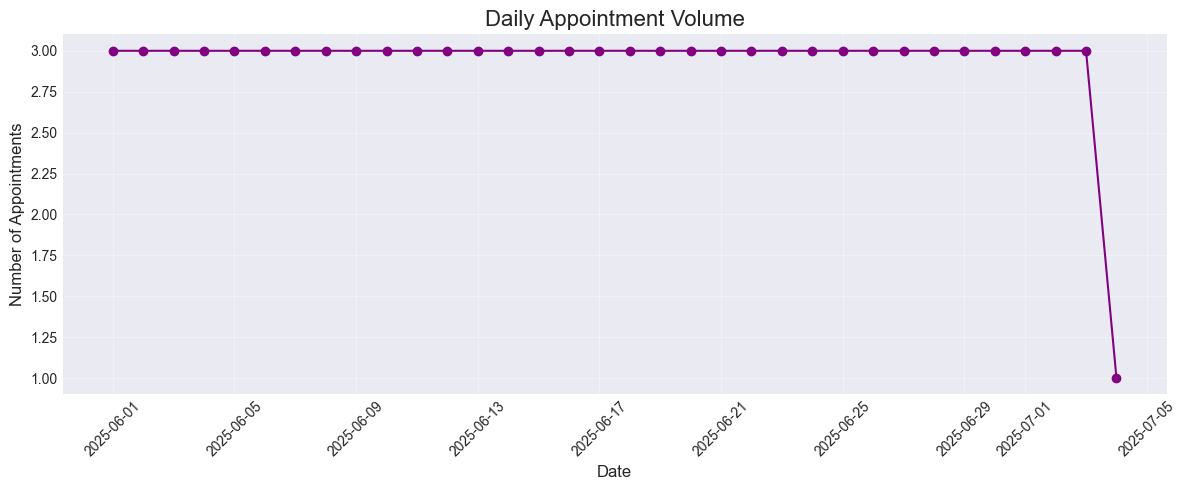

📅 Busiest day: 2025-06-01 (3 appointments)
📅 Quietest day: 2025-07-04 (1 appointments)


In [10]:
# Convert to datetime
appointments['appointment_date'] = pd.to_datetime(appointments['appointment_date'])

# Count appointments per day
daily_appointments = appointments.groupby(appointments['appointment_date']).size()

plt.figure(figsize=(12, 5))
plt.plot(daily_appointments.index, daily_appointments.values, marker='o', linestyle='-', color='purple')
plt.title('Daily Appointment Volume', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Appointments', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📅 Busiest day: {daily_appointments.idxmax().date()} ({daily_appointments.max()} appointments)")
print(f"📅 Quietest day: {daily_appointments.idxmin().date()} ({daily_appointments.min()} appointments)")

In [11]:
print("=" * 50)
print("PREDICTION MODEL: Will a patient miss their appointment?")
print("=" * 50)

# Merge data
appt_data = appointments.merge(patients[['patient_id', 'age']], on='patient_id')
appt_data = appt_data.merge(doctors[['doctor_id', 'name']], on='doctor_id')

# Create target variable (1 if cancelled, 0 if completed/scheduled)
appt_data['no_show'] = (appt_data['status'] == 'Cancelled').astype(int)

# Create features
appt_data['day_of_week'] = pd.to_datetime(appt_data['appointment_date']).dt.dayofweek

# Count appointments per doctor (popularity)
doctor_popularity = appointments.groupby('doctor_id').size().to_dict()
appt_data['doctor_popularity'] = appt_data['doctor_id'].map(doctor_popularity)

# Count appointments per patient (frequency)
patient_frequency = appointments.groupby('patient_id').size().to_dict()
appt_data['patient_frequency'] = appt_data['patient_id'].map(patient_frequency)

# Select features for model
features = ['age', 'day_of_week', 'doctor_popularity', 'patient_frequency']
X = appt_data[features].fillna(0)
y = appt_data['no_show']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy:.2%}")
print(f"\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})
print(f"\n📈 Feature Importance (higher = more likely to no-show):")
print(feature_importance.sort_values('coefficient', ascending=False))

PREDICTION MODEL: Will a patient miss their appointment?

✅ Model Accuracy: 90.00%

📊 Confusion Matrix:
[[27  0]
 [ 3  0]]

📈 Feature Importance (higher = more likely to no-show):
             feature  coefficient
1        day_of_week     0.085101
0                age     0.003542
3  patient_frequency    -0.000034
2  doctor_popularity    -0.059852


In [12]:
print("\n" + "=" * 60)
print("📋 BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
1. 👨‍⚕️ **Doctor Performance**
   - Top doctors have more visits than bottom doctors
   - Consider mentoring or support for low-performing doctors

2. 🏢 **Insurance Partners**
   - Some insurance companies have 0% approval rate → needs investigation
   - High-approval insurers should be featured to patients

3. 🏥 **Specialty Demand**
   - General Medicine has highest demand
   - Consider hiring more General practitioners

4. ⏰ **No-Show Prediction**
   - ML model can predict which patients might miss appointments
   - Send reminders to high-risk patients before their visit

5. 📊 **Data Quality**
   - Some ages >120 years → data entry issue to fix
   - Missing phone numbers → collect during registration
""")

print("\n🔮 NEXT STEPS FOR GAMMAL.TECH:")
print("- Integrate no-show prediction into booking system")
print("- Investigate low-approval insurance companies")
print("- Implement patient reminders for high-risk appointments")
print("- Add data validation rules to prevent bad data entry")


📋 BUSINESS RECOMMENDATIONS

1. 👨‍⚕️ **Doctor Performance**
   - Top doctors have more visits than bottom doctors
   - Consider mentoring or support for low-performing doctors

2. 🏢 **Insurance Partners**
   - Some insurance companies have 0% approval rate → needs investigation
   - High-approval insurers should be featured to patients

3. 🏥 **Specialty Demand**
   - General Medicine has highest demand
   - Consider hiring more General practitioners

4. ⏰ **No-Show Prediction**
   - ML model can predict which patients might miss appointments
   - Send reminders to high-risk patients before their visit

5. 📊 **Data Quality**
   - Some ages >120 years → data entry issue to fix
   - Missing phone numbers → collect during registration


🔮 NEXT STEPS FOR GAMMAL.TECH:
- Integrate no-show prediction into booking system
- Investigate low-approval insurance companies
- Implement patient reminders for high-risk appointments
- Add data validation rules to prevent bad data entry
